<a href="https://colab.research.google.com/github/pranav-1205/CSL701-Roll_No_CS47_Machine-Learning-Lab/blob/main/Experiments/Experiment_06_Support_Vector_Machine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 6

Name : Pranav Vivek Sadwelkar

Roll No : 47 Batch: CS-03

Aim

To implement Support Vector Machine (SVM) for classification of the Iris dataset and visualize its decision boundary and compare it with a normal linear classification boundary.

## Objectives

1. To understand the concept of Support Vector Machine.
2. To implement SVM using Python.
3. To visualize the SVM decision boundary.
4. To identify the support vectors.
5. To compare the SVM boundary with a normal linear classification boundary.
6. To evaluate the performance of the classifiers.

# Relevant Theory

### Support Vector Machine

Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification.

SVM finds a decision boundary that separates different classes while trying to maximize the distance, called the **margin**, between the classes.

The points closest to the decision boundary are called **support vectors**.

For a linear SVM, the decision boundary can be represented as:

$$
w^T x + b = 0
$$

where:

- $w$ = weight vector
- $x$ = input features
- $b$ = bias


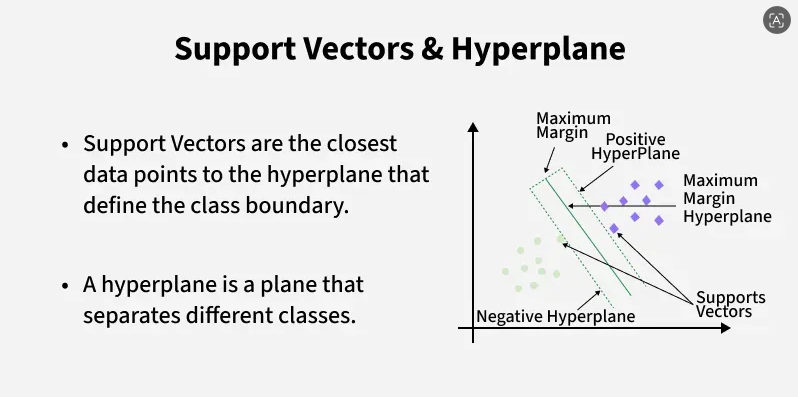
### Kernel

SVM can use different kernels to create decision boundaries.

Common kernels are:

- Linear
- Polynomial
- RBF
- Sigmoid

In this experiment, we mainly use the **Linear SVM** and **RBF SVM**.

---

# Dataset Information

Get the IRIS dataset from Kaggle using below link

https://www.kaggle.com/datasets/uciml/iris

The Iris dataset contains measurements of Iris flowers belonging to three classes:

- Iris-setosa
- Iris-versicolor
- Iris-virginica

The four features are:

- Sepal Length
- Sepal Width
- Petal Length
- Petal Width

For visualization, we will use:

**Petal Length and Petal Width.**

# Task 1: Import Libraries and Load Dataset

Load the Iris dataset.

---

In [1]:
# Task 1: Import Libraries and Load Dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Load the Iris dataset
df = pd.read_csv("Iris.csv")

print("Dataset loaded successfully.")
print("Shape:", df.shape)
df.head()


Dataset loaded successfully.
Shape: (150, 6)


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


# Task 2: Explore the Dataset

In [2]:
# Task 2: Explore the Dataset

print("Dataset shape:", df.shape)
print("\nColumn names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

print("\nLast 5 rows:")
display(df.tail())

print("\nDataset information:")
df.info()

print("\nMissing values:")
print(df.isnull().sum())

print("\nClass distribution:")
print(df["Species"].value_counts())

print("\nStatistical summary:")
display(df.describe())


Dataset shape: (150, 6)

Column names:
['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']

First 5 rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa



Last 5 rows:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica
149,150,5.9,3.0,5.1,1.8,Iris-virginica



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

Class distribution:
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

Statistical summary:


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


# Task 3: Select Features and Target

Remove the `Id` column.

Select Remaining Features

In [3]:
# Task 3: Select Features and Target

# Remove the Id column because it is only an identifier.
X = df.drop(columns=["Id", "Species"])
y = df["Species"]

print("Features:")
print(X.columns.tolist())

print("\nTarget classes:")
print(y.unique())

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)


Features:
['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

Target classes:
['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']

Feature shape: (150, 4)
Target shape: (150,)


# Task 4: Split and Scale the Data

Divide the dataset into training and testing sets.

In [4]:
# Task 4: Split and Scale the Data

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Standardize the features.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("\nData scaling completed.")


Training samples: 120
Testing samples: 30

Data scaling completed.


# Task 5: Implement Linear SVM

Create an SVM model using a **linear kernel**.

Make predictions.

In [5]:
# Task 5: Implement Linear SVM

# Create and train a Linear SVM.
svm_model = SVC(kernel="linear", C=1.0)
svm_model.fit(X_train_scaled, y_train)

# Make predictions.
y_pred_svm = svm_model.predict(X_test_scaled)

print("Linear SVM training completed.")
print("Number of support vectors for each class:",
      svm_model.n_support_)
print("Total support vectors:", len(svm_model.support_))


Linear SVM training completed.
Number of support vectors for each class: [ 2 11 10]
Total support vectors: 23


# Task 6: Evaluate SVM

### Calculate Accuracy

Calculate the accuracy of the SVM model.

### Confusion Matrix

Generate the confusion matrix to evaluate the classification results.

### Classification Report

Generate the classification report containing:

- Precision
- Recall
- F1-Score
- Support

---


Linear SVM Accuracy: 1.0

Confusion Matrix:
[[10  0  0]
 [ 0 10  0]
 [ 0  0 10]]


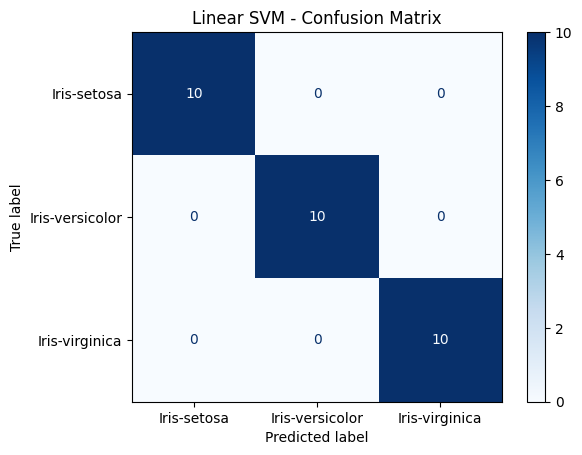


Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00        10
 Iris-virginica       1.00      1.00      1.00        10

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



In [6]:
# Task 6: Evaluate SVM

# Accuracy
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print("Linear SVM Accuracy:", svm_accuracy)

# Confusion Matrix
svm_cm = confusion_matrix(y_test, y_pred_svm, labels=svm_model.classes_)
print("\nConfusion Matrix:")
print(svm_cm)

ConfusionMatrixDisplay(
    confusion_matrix=svm_cm,
    display_labels=svm_model.classes_
).plot(cmap="Blues")
plt.title("Linear SVM - Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))


# Task 7: Visualize SVM Decision Boundary

For visualization, we use only two features:

- Petal Length
- Petal Width

### Create the 2-D Dataset

Select **Petal Length** and **Petal Width** as the input features.

### Split the Data

Divide the 2-D dataset into training and testing sets.

### Scale the Data

Standardize the selected features before training the SVM model.

### Train SVM

Train an SVM classifier using a **linear kernel**.

### Plot Decision Boundary

Visualize the SVM decision boundary along with the data points.

---

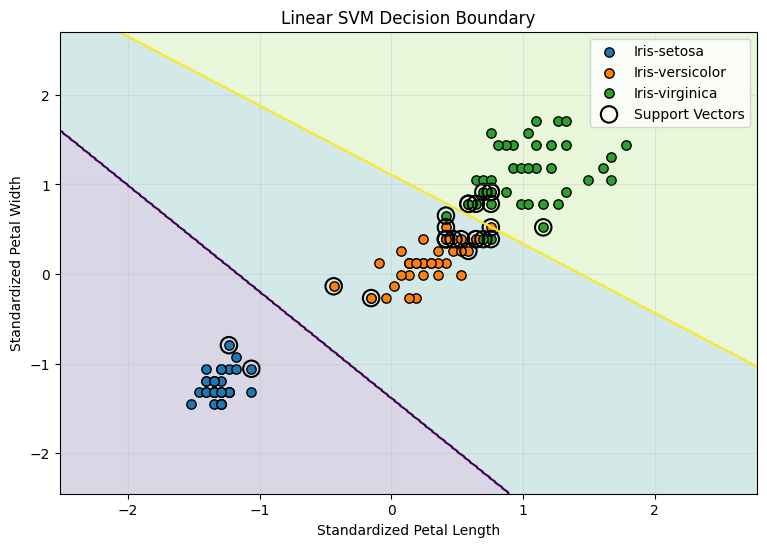

Number of support vectors for each class: [ 2 13 10]
Total support vectors: 25


In [7]:
# Task 7: Visualize SVM Decision Boundary

# Select Petal Length and Petal Width.
X_2d = df[["PetalLengthCm", "PetalWidthCm"]]
y_2d = df["Species"]

# Split the 2-D dataset using the same random state and stratification.
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X_2d, y_2d,
    test_size=0.20,
    random_state=42,
    stratify=y_2d
)

# Scale the 2-D features.
scaler_2d = StandardScaler()
X2_train_scaled = scaler_2d.fit_transform(X2_train)
X2_test_scaled = scaler_2d.transform(X2_test)

# Train Linear SVM.
svm_2d = SVC(kernel="linear", C=1.0)
svm_2d.fit(X2_train_scaled, y2_train)

def plot_decision_boundary(model, X_scaled, y, scaler, title):
    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 500),
        np.linspace(y_min, y_max, 500)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)

    class_to_num = {cls: i for i, cls in enumerate(model.classes_)}
    Z_num = np.array([class_to_num[v] for v in Z]).reshape(xx.shape)
    y_num = np.array([class_to_num[v] for v in y])

    plt.figure(figsize=(9, 6))
    plt.contourf(xx, yy, Z_num, alpha=0.20, levels=np.arange(len(model.classes_) + 1) - 0.5)
    plt.contour(xx, yy, Z_num, levels=np.arange(len(model.classes_) - 1) + 0.5)

    for cls in model.classes_:
        mask = y == cls
        plt.scatter(
            X_scaled[mask, 0],
            X_scaled[mask, 1],
            label=cls,
            edgecolor="black",
            s=45
        )

    # Highlight support vectors (only SVM models have them;
    # Logistic Regression does not, so skip it there).
    if hasattr(model, "support_vectors_"):
        plt.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=140,
            facecolors="none",
            edgecolors="black",
            linewidths=1.5,
            label="Support Vectors"
        )

    plt.xlabel("Standardized Petal Length")
    plt.ylabel("Standardized Petal Width")
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.25)
    plt.show()

plot_decision_boundary(
    svm_2d,
    X2_train_scaled,
    y2_train.to_numpy(),
    scaler_2d,
    "Linear SVM Decision Boundary"
)

print("Number of support vectors for each class:", svm_2d.n_support_)
print("Total support vectors:", len(svm_2d.support_))


# Task 8: Normal Linear Classification Boundary

For comparison, we use **Logistic Regression** as a normal linear classifier.

Train a Logistic Regression model using the same two features and visualize its decision boundary.

---

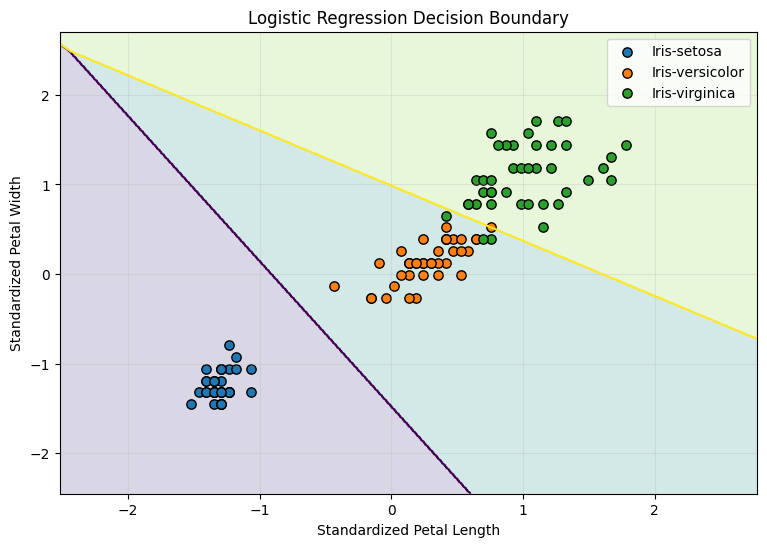

Logistic Regression Accuracy: 0.9333333333333333


In [8]:
# Task 8: Normal Linear Classification Boundary

# Logistic Regression is used as a normal linear classifier.
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X2_train_scaled, y2_train)

y2_pred_log = log_model.predict(X2_test_scaled)

plot_decision_boundary(
    log_model,
    X2_train_scaled,
    y2_train.to_numpy(),
    scaler_2d,
    "Logistic Regression Decision Boundary"
)

print("Logistic Regression Accuracy:",
      accuracy_score(y2_test, y2_pred_log))


# Task 9: Compare SVM and Normal Boundary

Plot both the **SVM** and **Logistic Regression** decision boundaries on the same graph.

Compare how the two classifiers separate the different classes.

---

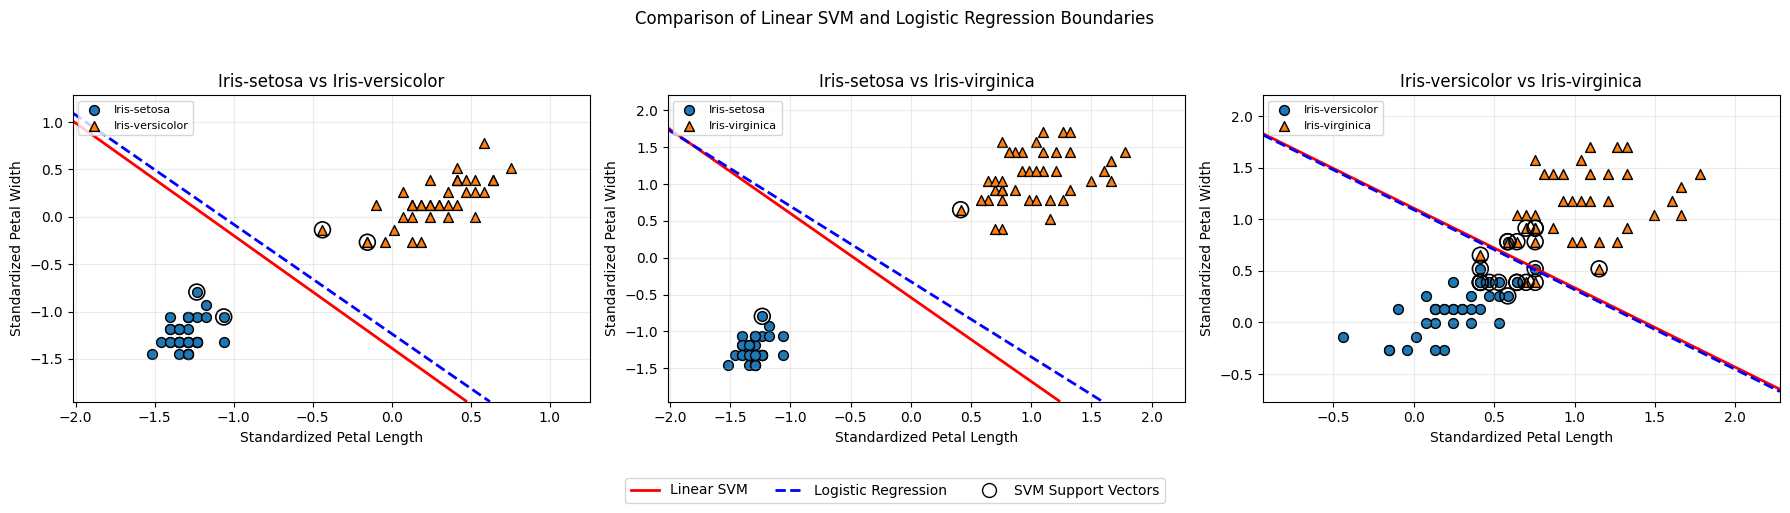

Solid lines  = Linear SVM pairwise boundaries
Dashed lines = Logistic Regression pairwise boundaries
Open circles = Linear SVM support vectors


In [9]:
# Task 9: Compare SVM and Normal Boundary

# For a clear 2-D comparison, plot pairwise linear boundaries for each
# combination of Iris classes. This gives an interpretable view of the
# separating hyperplanes for both Linear SVM and Logistic Regression.

from itertools import combinations

classes = np.unique(y2_train)
class_pairs = list(combinations(classes, 2))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (class_a, class_b) in zip(axes, class_pairs):
    mask = y2_train.isin([class_a, class_b])

    X_pair = X2_train_scaled[mask.to_numpy()]
    y_pair = y2_train[mask].to_numpy()

    # Binary labels: 0 for class_a and 1 for class_b
    y_binary = (y_pair == class_b).astype(int)

    pair_svm = SVC(kernel="linear", C=1.0)
    pair_log = LogisticRegression(max_iter=1000, random_state=42)

    pair_svm.fit(X_pair, y_binary)
    pair_log.fit(X_pair, y_binary)

    x_min, x_max = X_pair[:, 0].min() - 0.5, X_pair[:, 0].max() + 0.5
    y_min, y_max = X_pair[:, 1].min() - 0.5, X_pair[:, 1].max() + 0.5

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    # Plot the two zero-level decision boundaries.
    svm_score = pair_svm.decision_function(grid).reshape(xx.shape)
    log_score = pair_log.decision_function(grid).reshape(xx.shape)

    ax.contour(xx, yy, svm_score, levels=[0], colors="red",
               linewidths=2, linestyles="-")
    ax.contour(xx, yy, log_score, levels=[0], colors="blue",
               linewidths=2, linestyles="--")

    for cls, marker in zip([class_a, class_b], ["o", "^"]):
        cls_mask = y_pair == cls
        ax.scatter(
            X_pair[cls_mask, 0],
            X_pair[cls_mask, 1],
            marker=marker,
            s=50,
            edgecolor="black",
            label=cls
        )

    # Highlight SVM support vectors.
    ax.scatter(
        pair_svm.support_vectors_[:, 0],
        pair_svm.support_vectors_[:, 1],
        s=130,
        facecolors="none",
        edgecolors="black",
        linewidths=1.2
    )

    ax.legend(handles=[h for h in ax.get_legend_handles_labels()[0]][:2],
              labels=[class_a, class_b], loc="upper left", fontsize=8)
    ax.set_title(f"{class_a} vs {class_b}")
    ax.set_xlabel("Standardized Petal Length")
    ax.set_ylabel("Standardized Petal Width")
    ax.grid(alpha=0.25)

# Matplotlib contour does not reliably display labels from `label=`,
# so provide one shared legend using proxy lines.
from matplotlib.lines import Line2D

legend_items = [
    Line2D([0], [0], color="red", linestyle="-", linewidth=2, label="Linear SVM"),
    Line2D([0], [0], color="blue", linestyle="--", linewidth=2, label="Logistic Regression"),
    Line2D([0], [0], marker="o", linestyle="None", markersize=10,
           markerfacecolor="none", markeredgecolor="black", label="SVM Support Vectors")
]

fig.legend(handles=legend_items, loc="lower center", ncol=3,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle("Comparison of Linear SVM and Logistic Regression Boundaries")
plt.tight_layout(rect=[0, 0.08, 1, 0.95])
plt.show()

print("Solid lines  = Linear SVM pairwise boundaries")
print("Dashed lines = Logistic Regression pairwise boundaries")
print("Open circles = Linear SVM support vectors")


# Task 10: Compare Performance

Compare the performance of the **Linear SVM** and **Logistic Regression** using:

- Accuracy
- Confusion Matrix
- Classification Report

---

In [10]:
# Task 10: Compare Performance

# Predictions on the same 2-D test set.
y2_pred_svm = svm_2d.predict(X2_test_scaled)
y2_pred_log = log_model.predict(X2_test_scaled)

svm_2d_accuracy = accuracy_score(y2_test, y2_pred_svm)
log_accuracy = accuracy_score(y2_test, y2_pred_log)

print("Performance Comparison")
print("=" * 50)
print(f"Linear SVM Accuracy        : {svm_2d_accuracy:.4f}")
print(f"Logistic Regression Accuracy: {log_accuracy:.4f}")

print("\nLinear SVM Confusion Matrix:")
print(confusion_matrix(y2_test, y2_pred_svm, labels=svm_2d.classes_))

print("\nLogistic Regression Confusion Matrix:")
print(confusion_matrix(y2_test, y2_pred_log, labels=log_model.classes_))

print("\nLinear SVM Classification Report:")
print(classification_report(y2_test, y2_pred_svm))

print("Logistic Regression Classification Report:")
print(classification_report(y2_test, y2_pred_log))


Performance Comparison
Linear SVM Accuracy        : 0.9333
Logistic Regression Accuracy: 0.9333

Linear SVM Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Logistic Regression Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]

Linear SVM Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Logistic Regression Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93     

# Conclusion

The experiment successfully demonstrated the implementation of **Support Vector Machine (SVM)** using the Iris dataset. The dataset was explored, the `Id` column was removed, and the features were standardized before training.

A **Linear SVM** was trained using all four features and evaluated using accuracy, confusion matrix, and classification report. The decision boundary was then visualized in two dimensions using **Petal Length** and **Petal Width**, with the support vectors highlighted.

For comparison, **Logistic Regression** was used as a normal linear classifier. Both classifiers produced linear decision boundaries and were compared using the same 2-D train/test split and evaluation measures.

Overall, the experiment shows how SVM uses support vectors and margin maximization to determine a separating boundary, while Logistic Regression learns a linear classification boundary using class probabilities.
